In [21]:
import sys, os
sys.path.append(os.path.join(os.path.expanduser('~'), 'Documents', 'GitHub', 'RiemannianEB', 'src'))
from utils import *
circle = Hypersphere(1)



In [40]:
n_samples = 1000
rho = 1e-5
all_num_modes =  [1, 2, 3, 4]
all_Ms = [3,5,6,9]
all_tau2s = [0.05, 0.03, 0.015, 0.01]
all_sigma2s = [0.015, 0.025, 0.05, .1, .15]
NMC = 10

In [41]:

all_records = []  # Collect all data across num_modes
for num_modes, tau2, M in zip(all_num_modes,all_tau2s, all_Ms):
    G_params = {'tau2': tau2/num_modes , 'num_modes': num_modes} 
    for sigma2 in all_sigma2s:
        loss_Ts, loss_Ns = [], []
        for imc in tqdm(range(NMC), desc=f'modes={num_modes}, σ²={sigma2}', leave = False ):
            Theta = S1_multimodal_prior(n_samples, G_params)
            X = circle.random_riemannian_normal(Theta, 1./np.sqrt(sigma2), n_samples)
            loss_N = (circle.metric.dist_broadcast(X, Theta)**2).mean()
            delta = denoiser('S1', X, M, rho, sigma2, X, )
            loss_T = (circle.metric.dist_broadcast(delta, Theta)**2).mean() 
            loss_Ts.append(loss_T); loss_Ns.append(loss_N)
        all_records.append(pd.DataFrame({
            "num_modes": [num_modes] * NMC,
            "sigma2": [sigma2] * NMC,
            "mc": np.arange(NMC),
            "Denoised": loss_Ts,
            "Naïve": loss_Ns
        }))

df = pd.concat(all_records, ignore_index=True)
df_long = df.melt(id_vars=["num_modes", "sigma2", "mc"], value_vars=["Denoised", "Naïve"],var_name="Loss Type",value_name="Loss")
df_box = (df_long.pivot(index=["num_modes", "sigma2", "mc"],columns="Loss Type",values="Loss").reset_index())
df_box["rel_impr"] = (1 - df_box["Denoised"] / df_box["Naïve"]) * 100


INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO: Using categori

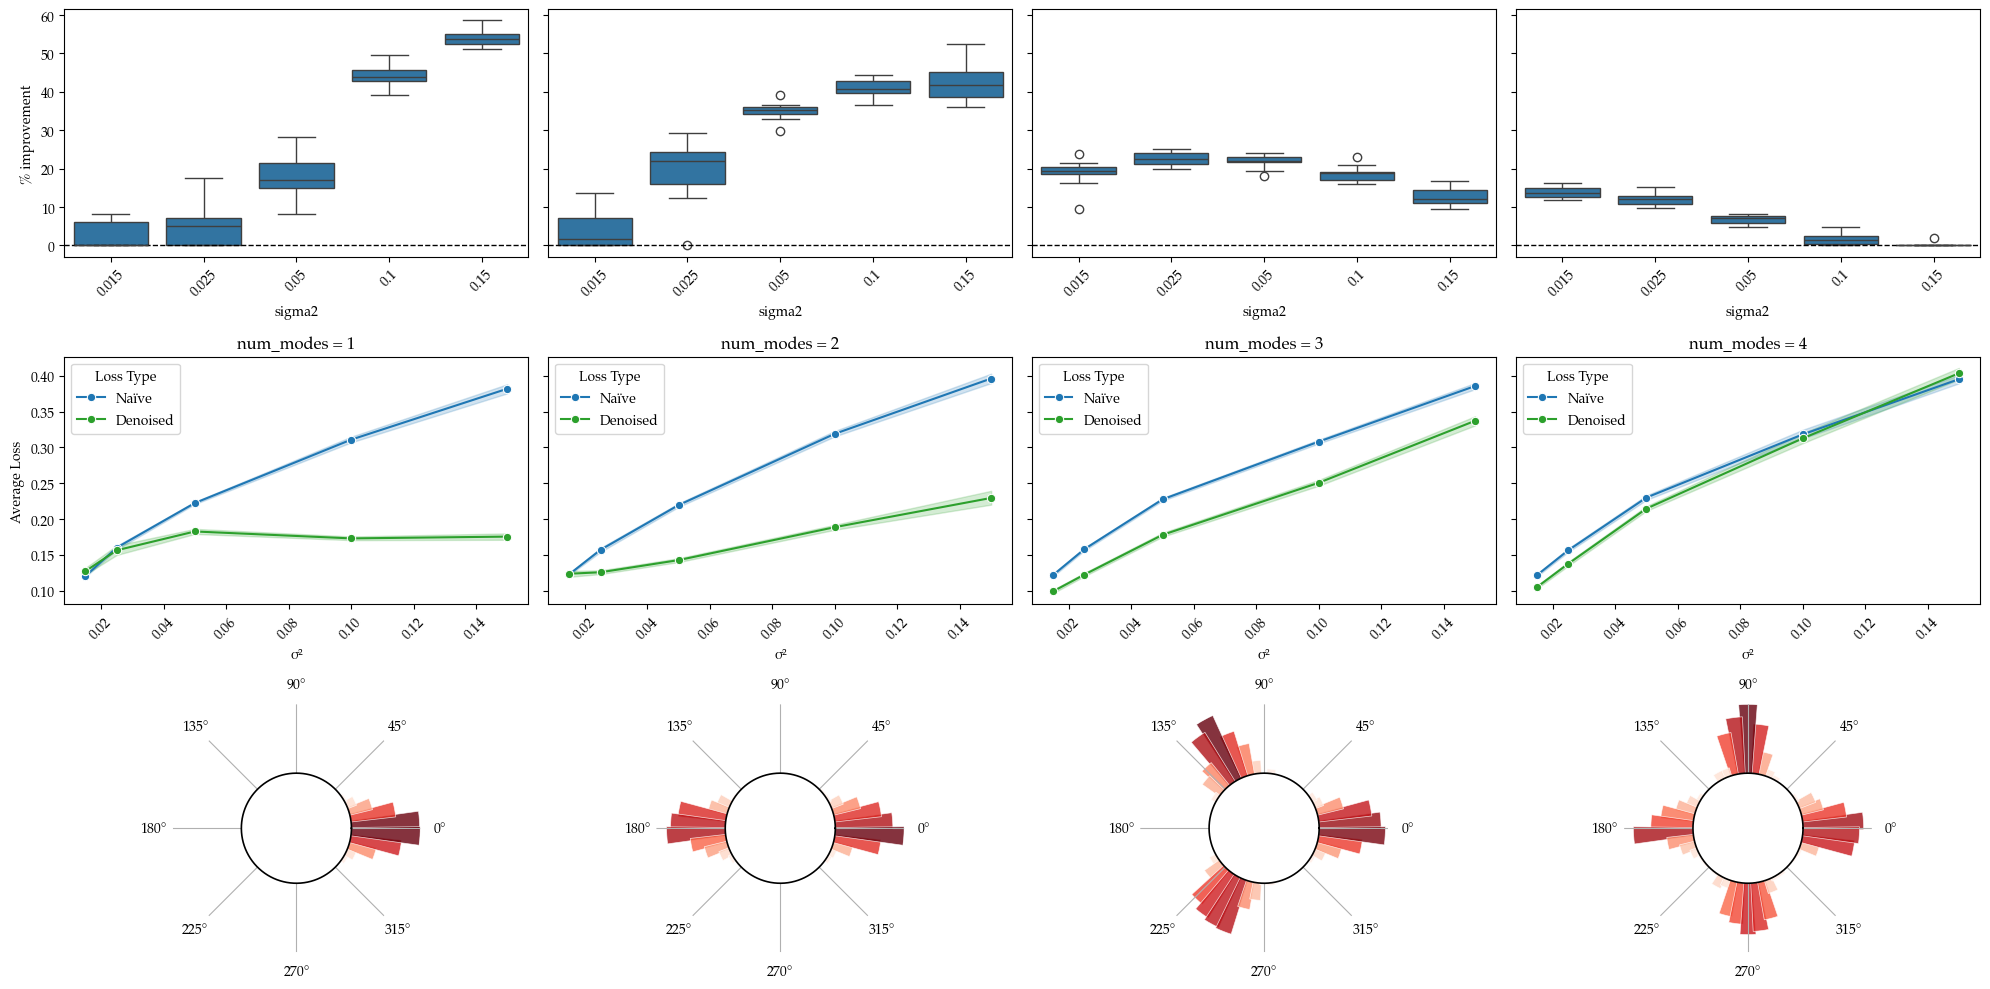

In [42]:
fig, axs = plt.subplots(3, len(all_num_modes), figsize=(20, 10))

for idx, (num_modes, M ) in enumerate(zip(all_num_modes, all_Ms)):
    df_subset = df_long[df_long['num_modes'] == num_modes]

    # clip negative improvements to 0 (do not overwrite the whole column each loop)
    df_box.loc[df_box["num_modes"] == num_modes, "rel_impr"] = np.maximum(
        df_box.loc[df_box["num_modes"] == num_modes, "rel_impr"].to_numpy(),
        0,
    )

    sns.boxplot(
    data=df_box[df_box["num_modes"] == num_modes],
        x='sigma2',
        y='rel_impr',
        ax=axs[0, idx]
    )
    axs[0, idx].axhline(0, ls='--', c='k', lw=1)
    axs[0, idx].set_ylabel('% improvement')
    axs[0, idx].tick_params(axis='x', rotation=45)


    sns.lineplot(
        data=df_subset,
        x="sigma2",
        y="Loss",
        hue="Loss Type",
        hue_order=["Naïve", "Denoised"],
        palette={"Naïve": "C0", "Denoised": "C2"},
        estimator="mean",
        errorbar=("ci", 68),  # 1-sigma style band; use 95 if you prefer
        marker="o",
        ax=axs[1, idx],
    )

    axs[1, idx].set_title(f"num_modes = {num_modes}")
    axs[1, idx].set_xlabel("σ²")
    axs[1, idx].set_ylabel("Average Loss")
    axs[1, idx].tick_params(axis='x', rotation=45)
    

    axs[2, idx].remove()
    axs[2, idx] = fig.add_subplot( 3, len(all_num_modes), idx + 2*len(all_num_modes) + 1, polar=True)

    Theta = S1_multimodal_prior(  n_samples, {'tau2': 5*tau2, 'num_modes': num_modes})
    Theta = circle.intrinsic_to_extrinsic_coords( circle.extrinsic_to_intrinsic_coords(Theta) - np.pi/12)
    # S1_smooth_histogram( Theta, params_to_M_dict[(num_modes, all_sigma2s[0])], axs[1, idx], 'Reds')
    S1_histogram(Theta, 50, axs[2, idx], 'Reds')


    # Share y-axes across rows and hide repeated y tick labels within each row
    for r in range(axs.shape[0]-1):
        base = axs[r, 0]
        for c in range(1, axs.shape[1]):
            axs[r, c].sharey(base)
            axs[r, c].set_ylabel("")
            axs[r, c].tick_params(labelleft=False)
plt.tight_layout()
plt.show()

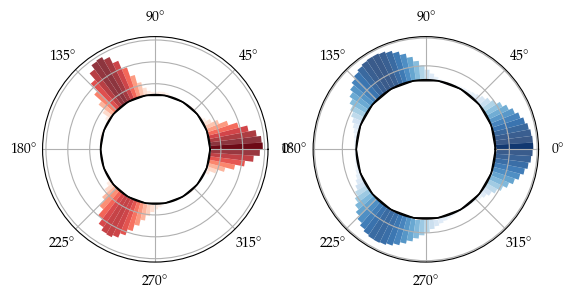

In [ ]:
fig, axs = plt.subplots(1, 2, subplot_kw={'projection': 'polar'})
Theta = S1_multimodal_prior(  n_samples, {'tau2': tau2, 'num_modes': 3})
sigma2 = 1e-2
X = circle.random_riemannian_normal(Theta, 1./np.sqrt(sigma2), n_samples)

S1_smooth_histogram( Theta, params_to_M_dict[(num_modes, all_sigma2s[0])], axs[0], 'Reds')
S1_smooth_histogram( X, params_to_M_dict[(num_modes, all_sigma2s[0])], axs[1], 'Blues')





In [ ]:
fig, axs = plt.subplots(1, 2, subplot_kw={'projection': 'polar'})
Theta = S1_multimodal_prior(  n_samples, {'tau2': tau2, 'num_modes': 3})
sigma2 = 1e-2
X = circle.random_riemannian_normal(Theta, 1./np.sqrt(sigma2), n_samples)

S1_histogram(Theta, 50, axs[0], 'Reds')
S1_histogram(X, 50, axs[1], 'Blues')
